# SVM-RBF feature subset search
Mirrors the ExtraTrees pipeline from notebook 05, but for SVM-RBF.

**Stage 1** - exhaustive search over all 120 subsets (k=2..7) of the 7
candidate features, single CV seed, 4 fixed HP configs.
**Stage 2** - Optuna HP tuning on the top-N subsets, multi-seed objective.

Speed note: `SVC(probability=False)` + `decision_function` is used throughout.
`sweep_cutoff` is fully rank-based, so the score is identical to the
`predict_proba` version used by ExtraTrees — no calibration needed.


In [ ]:
!pip install optuna -q


In [1]:
import os, json, time, warnings
from itertools import chain, combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_predict

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")


In [ ]:
ON_KAGGLE = os.path.exists("/kaggle")
DATA_DIR  = Path(
    "/kaggle/input/datasets/bolesawpaliwoda/aml-project-2/data"
    if ON_KAGGLE else "../data"
)
OUT_DIR = Path("/kaggle/working" if ON_KAGGLE else ".")

TRAIN_X = DATA_DIR / "processed" / "x_train_scaled_reduced_after_mi.csv"
TRAIN_Y = DATA_DIR / "y_train.txt"

CANDIDATES = ["V176", "V255", "V191", "V160", "V215", "V380", "V342"]

CV_FOLDS     = 5
RANDOM_STATE = 0  
CAP          = 1000

FIXED_SVM_CONFIGS = [
    dict(kernel="rbf", C=1.0,  gamma="scale"),
    dict(kernel="rbf", C=10.0, gamma="scale"),
    dict(kernel="rbf", C=1.0,  gamma="auto"),
    dict(kernel="rbf", C=0.1,  gamma="scale"),
]

TOP_N_OPTUNA  = 5
OPTUNA_TRIALS = 60

OPTUNA_SEEDS = [0, 1, 2]

def _load_et(path="best_config.json"):
    for cand in [Path(path), OUT_DIR / "best_config.json"]:
        if cand.exists():
            cfg = json.load(open(cand))
            print(f"ET reference loaded: k={cfg['k']}  "
                  f"mean={cfg.get('mean_score','?')}  features={cfg['features']}")
            return cfg
    print("best_config.json not found - ET reference unavailable")
    return None

ET_CFG = _load_et()

print(f"Subsets k=2..7: {sum(1 for k in range(2,8) for _ in combinations(CANDIDATES,k))}")
print(f"Selection seeds: {OPTUNA_SEEDS}")


best_config.json not found — ET reference unavailable
Subsets k=2..7: 120
Selection seeds: [0, 1, 2]


In [6]:
def sweep_cutoff(y_true, scores, n_vars, cap=CAP):
    """Rank-based OOF cost scoring. Works with predict_proba[:,1] or
    decision_function output — ordering is all that matters."""
    order = np.argsort(-scores)
    best_s, best_n = -np.inf, 0
    for n in range(1, min(cap, len(scores)) + 1):
        tp = int(np.sum(y_true[order[:n]] == 1))
        s  = tp * 10 - (n - tp) * 5 - n_vars * 200
        if s > best_s:
            best_s, best_n = s, n
    if best_n == 0:
        return int(best_s), 0, 0.0, 0, 0
    tp_best  = int(np.sum(y_true[order[:best_n]] == 1))
    thr_best = float(scores[order[best_n - 1]])
    return int(best_s), best_n, thr_best, tp_best, best_n - tp_best


def oof_svm(X_arr, y, hp, n_vars, seed=RANDOM_STATE):
    """Single-seed OOF using decision_function (fast, rank-equivalent)."""
    model = SVC(**hp, probability=False, random_state=seed)
    skf   = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=seed)
    df    = cross_val_predict(model, X_arr, y, cv=skf,
                              method="decision_function", n_jobs=1)
    return sweep_cutoff(y, df, n_vars)


def oof_svm_multiseed(X_arr, y, C, gamma, n_vars, seeds=OPTUNA_SEEDS):
    """Multi-seed mean OOF — honest objective for Optuna."""
    scores = []
    for s in seeds:
        model = SVC(kernel="rbf", C=C, gamma=gamma,
                    probability=False, random_state=s)
        skf   = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=s)
        df    = cross_val_predict(model, X_arr, y, cv=skf,
                                  method="decision_function", n_jobs=1)
        scores.append(sweep_cutoff(y, df, n_vars)[0])
    return float(np.mean(scores)), float(np.std(scores)), scores


def all_subsets(elements, min_k=2, max_k=None):
    max_k = max_k or len(elements)
    return list(chain.from_iterable(
        combinations(elements, k) for k in range(min_k, max_k + 1)))


In [7]:
X_df = pd.read_csv(TRAIN_X)
y    = np.loadtxt(TRAIN_Y, skiprows=1).astype(int)
print(f"X_train {X_df.shape}   positive rate {y.mean():.3f}")
assert all(c in X_df.columns for c in CANDIDATES)


X_train (5000, 493)   positive rate 0.498


## Stage 1 - exhaustive subset search (single seed, fixed HP)

In [8]:
subsets = all_subsets(CANDIDATES)
rows    = []
t0      = time.time()

for i, subset in enumerate(subsets):
    feats = list(subset)
    k     = len(feats)
    X_arr = X_df[feats].to_numpy()
    best  = None

    for hp in FIXED_SVM_CONFIGS:
        score, N, thr, tp, fp = oof_svm(X_arr, y, hp, n_vars=k)
        if best is None or score > best["score"]:
            best = dict(score=score, k=k, N=N, thr=thr, tp=tp, fp=fp,
                        features=feats, hp=hp)

    rows.append(best)
    eta = (time.time() - t0) / (i + 1) * (len(subsets) - i - 1)
    print(f"[{i+1:3d}/{len(subsets)}] k={k}  {feats}  "
          f"score={best['score']}  ETA {eta/60:.1f}min")

results1 = (pd.DataFrame(rows)
            .sort_values("score", ascending=False)
            .reset_index(drop=True))
print(f"\nStage 1 done: {(time.time()-t0)/60:.1f} min")
results1.to_csv(OUT_DIR / "svm_stage1.csv", index=False)


[  1/120] k=2  ['V176', 'V255']  score=4965  ETA 52.4min
[  2/120] k=2  ['V176', 'V191']  score=4815  ETA 52.0min
[  3/120] k=2  ['V176', 'V160']  score=4935  ETA 49.1min
[  4/120] k=2  ['V176', 'V215']  score=4550  ETA 48.6min
[  5/120] k=2  ['V176', 'V380']  score=4740  ETA 48.3min
[  6/120] k=2  ['V176', 'V342']  score=4650  ETA 47.6min
[  7/120] k=2  ['V255', 'V191']  score=4665  ETA 47.4min
[  8/120] k=2  ['V255', 'V160']  score=4875  ETA 50.3min
[  9/120] k=2  ['V255', 'V215']  score=4740  ETA 53.2min
[ 10/120] k=2  ['V255', 'V380']  score=4900  ETA 54.5min
[ 11/120] k=2  ['V255', 'V342']  score=4710  ETA 53.4min
[ 12/120] k=2  ['V191', 'V160']  score=4755  ETA 52.2min
[ 13/120] k=2  ['V191', 'V215']  score=4505  ETA 51.4min
[ 14/120] k=2  ['V191', 'V380']  score=4635  ETA 52.6min
[ 15/120] k=2  ['V191', 'V342']  score=4595  ETA 53.5min
[ 16/120] k=2  ['V160', 'V215']  score=4845  ETA 54.3min
[ 17/120] k=2  ['V160', 'V380']  score=4805  ETA 54.9min
[ 18/120] k=2  ['V160', 'V342']

,k,score,N,tp,fp,precision@N,features
0,2,4965,1000,691,309,0.691000,"['V176', 'V255']"
1,3,5365,1000,731,269,0.731000,"['V176', 'V255', 'V160']"
2,4,5525,1000,755,245,0.755000,"['V176', 'V255', 'V160', 'V215']"
3,5,5705,999,780,219,0.781000,"['V255', 'V191', 'V160', 'V380', 'V342']"
4,6,5590,1000,786,214,0.786000,"['V176', 'V255', 'V191', 'V215', 'V380', 'V342']"
5,7,5465,1000,791,209,0.791000,"['V176', 'V255', 'V191', 'V160', 'V215', 'V380', 'V342']"


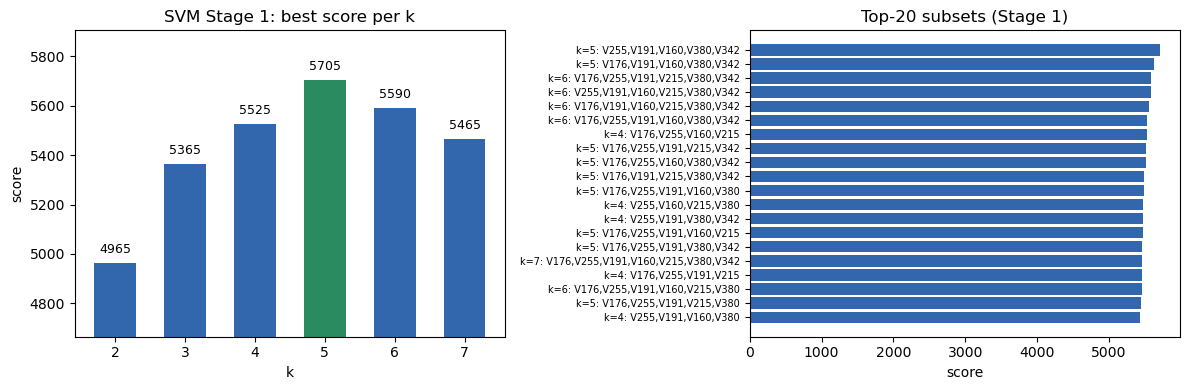

Global best Stage 1: score=5705  k=5  ['V255', 'V191', 'V160', 'V380', 'V342']


In [9]:
best_per_k = results1.groupby("k").first().reset_index()
best_per_k["precision@N"] = (best_per_k["tp"] / best_per_k["N"]).round(3)
display(best_per_k[["k","score","N","tp","fp","precision@N","features"]]
        .style.highlight_max(subset=["score"], color="#c6efce"))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

k_vals = best_per_k["k"].tolist()
scores = best_per_k["score"].tolist()
colors = ["#2a8a60" if s == max(scores) else "#3266ad" for s in scores]
ax1.bar(k_vals, scores, color=colors, width=0.6)
ax1.set_xlabel("k"); ax1.set_ylabel("score")
ax1.set_title("SVM Stage 1: best score per k")
ax1.set_ylim(min(scores) - 300, max(scores) + 200)
for k, s in zip(k_vals, scores):
    ax1.text(k, s + 40, str(s), ha="center", fontsize=9)

top20 = results1.head(20).copy()
top20["label"] = top20.apply(
    lambda r: f"k={r['k']}: {','.join(r['features'])}", axis=1)
yp = range(len(top20))
ax2.barh(list(yp), top20["score"].tolist(), color="#3266ad")
ax2.set_yticks(list(yp))
ax2.set_yticklabels(top20["label"].tolist(), fontsize=7)
ax2.invert_yaxis(); ax2.set_xlabel("score")
ax2.set_title("Top-20 subsets (Stage 1)")

plt.tight_layout(); plt.savefig(OUT_DIR / "svm_stage1.png", dpi=150); plt.show()
print(f"Global best Stage 1: score={results1.iloc[0]['score']}  "
      f"k={results1.iloc[0]['k']}  {results1.iloc[0]['features']}")


## Stage 2 - Optuna HP tuning on top subsets (multi-seed)

In [10]:
optuna_rows = []
t0 = time.time()

for rank, (_, row) in enumerate(results1.head(TOP_N_OPTUNA).iterrows(), 1):
    feats = row["features"]
    k     = len(feats)
    X_arr = X_df[feats].to_numpy()
    gamma_init = 1.0 / k          # ≈ gamma="scale" for standardised data

    # multi-seed baseline with the best Stage-1 fixed config
    best_fixed_hp = row["hp"]
    C0 = best_fixed_hp["C"]
    g0 = best_fixed_hp.get("gamma", "scale")
    g0_f = gamma_init if isinstance(g0, str) else g0
    fixed_mean, _, _ = oof_svm_multiseed(X_arr, y, C=C0, gamma=g0_f, n_vars=k)

    print(f"\n[{rank}/{TOP_N_OPTUNA}] k={k}  {feats}")
    print(f"   fixed-HP multiseed baseline = {fixed_mean:.0f}  "
          f"(stage1 seed0 = {row['score']})")

    def objective(trial):
        C     = trial.suggest_float("C",     0.01, 200.0, log=True)
        gamma = trial.suggest_float("gamma", 1e-4,  10.0, log=True)
        mean_s, _, _ = oof_svm_multiseed(X_arr, y, C=C, gamma=gamma, n_vars=k)
        return mean_s

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    # warm-start with sensible SVM operating points
    for C_w, g_w in [(1.0, gamma_init), (10.0, gamma_init),
                     (1.0, 0.01), (0.1, gamma_init * 2)]:
        study.enqueue_trial({"C": C_w, "gamma": g_w})

    study.optimize(objective, n_trials=OPTUNA_TRIALS, show_progress_bar=True)

    mean_s, std_s, per_seed = oof_svm_multiseed(
        X_arr, y, C=study.best_params["C"],
        gamma=study.best_params["gamma"], n_vars=k)
    s0, N0, thr0, tp0, fp0 = oof_svm(X_arr, y,
        dict(kernel="rbf", **study.best_params), n_vars=k)

    print(f"   -> Optuna multiseed: {mean_s:.0f} +/- {std_s:.0f}  "
          f"({mean_s - fixed_mean:+.0f} vs fixed)   seed0={s0} N={N0} TP={tp0}")

    optuna_rows.append(dict(score=mean_s, std=std_s, per_seed=per_seed,
                            fixed_baseline=fixed_mean, seed0_score=s0,
                            k=k, N=N0, thr=thr0, tp=tp0, fp=fp0,
                            features=feats, hp=study.best_params))

results2 = (pd.DataFrame(optuna_rows)
            .sort_values("score", ascending=False)
            .reset_index(drop=True))
print(f"\nStage 2 done: {(time.time()-t0)/60:.1f} min")



[1/5] k=5  ['V255', 'V191', 'V160', 'V380', 'V342']
   fixed-HP multiseed baseline = 5615  (stage1 seed0 = 5705)


  0%|          | 0/60 [00:00<?, ?it/s]

   -> Optuna multiseed: 5638 +/- 38  (+23 vs fixed)   seed0=5585 N=999 TP=772

[2/5] k=5  ['V176', 'V191', 'V160', 'V380', 'V342']
   fixed-HP multiseed baseline = 5507  (stage1 seed0 = 5625)


  0%|          | 0/60 [00:00<?, ?it/s]

   -> Optuna multiseed: 5560 +/- 35  (+53 vs fixed)   seed0=5535 N=1000 TP=769

[3/5] k=6  ['V176', 'V255', 'V191', 'V215', 'V380', 'V342']
   fixed-HP multiseed baseline = 5495  (stage1 seed0 = 5590)


...

   -> Optuna multiseed: 5547 +/- 35  (+52 vs fixed)   seed0=5545 N=1000 TP=783

[4/5] k=6  ['V255', 'V191', 'V160', 'V215', 'V380', 'V342']
   fixed-HP multiseed baseline = 5570  (stage1 seed0 = 5590)


  0%|          | 0/60 [00:00<?, ?it/s]

   -> Optuna multiseed: 5598 +/- 52  (+28 vs fixed)   seed0=5635 N=1000 TP=789

[5/5] k=6  ['V176', 'V191', 'V160', 'V215', 'V380', 'V342']
   fixed-HP multiseed baseline = 5538  (stage1 seed0 = 5565)


  0%|          | 0/60 [00:00<?, ?it/s]

   -> Optuna multiseed: 5538 +/- 45  (+0 vs fixed)   seed0=5565 N=999 TP=784

Stage 2 done: 167.1 min


In [11]:
results2.to_csv(OUT_DIR / "svm_stage2.csv", index=False)

best_svm = results2.iloc[0]

print("=" * 56)
print("BEST SVM RESULT  (multi-seed selection)")
print(f"  mean score : {best_svm['score']:.0f} +/- {best_svm['std']:.0f}"
      f"   seeds={OPTUNA_SEEDS}")
print(f"  seed0 score: {best_svm['seed0_score']}")
print(f"  k          : {best_svm['k']}  features: {best_svm['features']}")
print(f"  C={best_svm['hp']['C']:.4f}   gamma={best_svm['hp']['gamma']:.5f}")
print("=" * 56)

if ET_CFG and "mean_score" in ET_CFG:
    et_mean = ET_CFG["mean_score"]
    delta   = best_svm["score"] - et_mean
    print(f"\nExtraTrees mean : {et_mean:.0f} +/- {ET_CFG.get('std_score', '?')}")
    print(f"SVM-RBF    mean : {best_svm['score']:.0f} +/- {best_svm['std']:.0f}")
    print(f"Delta           : {delta:+.0f}  (SVM - ET)")

display(results2[["score","std","seed0_score","k","N","tp","fp","features"]]
        .assign(**{"prec@N": lambda d: (d.tp/d.N).map("{:.1%}".format)})
        .style.highlight_max(subset=["score"], color="#c6efce"))


BEST SVM RESULT  (multi-seed selection)
  mean score : 5638 +/- 38   seeds=[0, 1, 2]
  seed0 score: 5585
  k          : 5  features: ['V255', 'V191', 'V160', 'V380', 'V342']
  C=0.0295   gamma=0.26164


,score,std,seed0_score,k,N,tp,fp,features,prec@N
0,5638.333333,37.932689,5585,5,999,772,227,"['V255', 'V191', 'V160', 'V380', 'V342']",77.3%
1,5598.333333,51.854497,5635,6,1000,789,211,"['V255', 'V191', 'V160', 'V215', 'V380', 'V342']",78.9%
2,5560.000000,35.355339,5535,5,1000,769,231,"['V176', 'V191', 'V160', 'V380', 'V342']",76.9%
3,5546.666667,34.721111,5545,6,1000,783,217,"['V176', 'V255', 'V191', 'V215', 'V380', 'V342']",78.3%
4,5538.333333,44.969125,5565,6,999,784,215,"['V176', 'V191', 'V160', 'V215', 'V380', 'V342']",78.5%


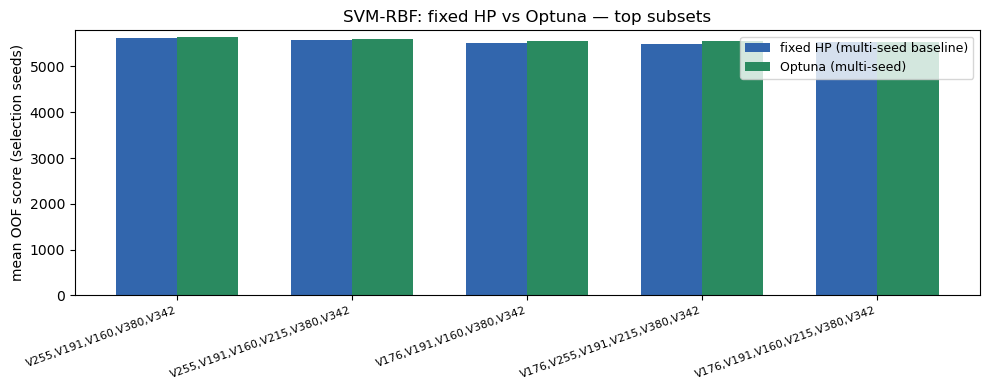

In [13]:
# Stage 1 vs Optuna per subset
comp = results2.copy()
comp["label"] = comp["features"].apply(lambda f: ",".join(f))

x, w = range(len(comp)), 0.35
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar([i - w/2 for i in x], comp["fixed_baseline"], width=w,
       label="fixed HP (multi-seed baseline)", color="#3266ad")
ax.bar([i + w/2 for i in x], comp["score"], width=w,
       label="Optuna (multi-seed)", color="#2a8a60")
if ET_CFG and "mean_score" in ET_CFG:
    ax.axhline(ET_CFG["mean_score"], color="#e24b4a", linestyle="--",
               lw=1.2, label=f"ExtraTrees best ({ET_CFG['mean_score']:.0f})")
ax.set_xticks(list(x))
ax.set_xticklabels(comp["label"].tolist(), rotation=20, ha="right", fontsize=8)
ax.set_ylabel("mean OOF score (selection seeds)")
ax.set_title("SVM-RBF: fixed HP vs Optuna — top subsets")
ax.legend(fontsize=9)
lo = min(comp["fixed_baseline"].min(), comp["score"].min())
hi = max(comp["fixed_baseline"].max(), comp["score"].max())
ax.set_ylim(0, hi + 150)
plt.tight_layout()
plt.savefig(OUT_DIR / "svm_stage2.png", dpi=150)
plt.show()


In [14]:
best_svm = results2.iloc[0]

with open(OUT_DIR / "svm_best_config.json", "w") as f:
    json.dump({
        "selection_seeds": OPTUNA_SEEDS,
        "mean_score": float(best_svm["score"]),
        "std_score":  float(best_svm["std"]),
        "per_seed":   list(best_svm["per_seed"]),
        "seed0_score":int(best_svm["seed0_score"]),
        "k":          int(best_svm["k"]),
        "features":   best_svm["features"],
        "N":          int(best_svm["N"]),
        "tp":         int(best_svm["tp"]),
        "fp":         int(best_svm["fp"]),
        "C":          float(best_svm["hp"]["C"]),
        "gamma":      float(best_svm["hp"]["gamma"]),
    }, f, indent=2)
print("Saved svm_best_config.json")


Saved svm_best_config.json
